# Fraud Detection — End-to-End MLOps on AWS

A **portfolio** project that demonstrates a realistic and **reproducible** MLOps flow:
train a **fraud detection** model (Fraud / Not Fraud), evaluate it with a **configurable**
metric, register it in the **Model Registry** only if it clears the threshold, deploy it to a
**real-time endpoint** and let **the arrival of new data trigger the pipeline** again.

```text
Synthetic dataset (sklearn) -> S3 Raw -> Processing -> Training -> Evaluation
  -> Conditional (metric >= threshold) -> Model Registry -> Approval -> Endpoint -> Inference
```

* **SageMaker Pipelines SDK V3** (the same patterns validated in this environment).
* This is the **thin** notebook: all the logic lives in [`src/fraud_mlops/`](src/fraud_mlops/)
  and the notebook only orchestrates the E2E demo in 14 sections.
* The original 53-cell notebook used to build the project is kept as a backup in
  `notebooks/archive/` (local; not published, see `.gitignore`).


## ONE-TIME MANUAL SETUP

* **AWS credentials** already configured on your machine (default profile).
* **Execution role** for SageMaker with full permissions (pipelines, processing, training,
  Model Registry, deployment and invoke). The notebook auto-detects `get_execution_role()`; if
  it fails, set the `SAGEMAKER_ROLE_ARN` environment variable before running.
* **Optional environment variables** (no code changes):

  | Variable | Purpose |
  |---|---|
  | `AWS_REGION` | AWS region (default `us-east-1`) |
  | `SAGEMAKER_ROLE_ARN` | Role ARN if auto-detection is not possible |
  | `SNS_ALERT_EMAIL` | Email to subscribe to the SNS alert topic |

* **S3 bucket**: the default SageMaker bucket is used (`sagemaker-<region>-<account>`).
* **Quota** `ml.m5.large`: processing + training + endpoint.

> Navigate to the project root and run the cells **in order**.
> Always read the **COST WARNING** notes before each step that consumes AWS.


## 1. Configuration

Every knob of the project lives in [`src/fraud_mlops/config.py`](src/fraud_mlops/config.py)
and is imported with a single line. They are **default** values: most of them can be overridden
on each **pipeline run** (parameters), as you will see in section 10.


In [ ]:
import sys
sys.path.insert(0, "src")   # the fraud_mlops package lives in src/

import json
import pandas as pd
from IPython.display import display

from dotenv import load_dotenv
load_dotenv()

from fraud_mlops import config

print("Pipeline:", config.PIPELINE_NAME, "| Region:", config.AWS_REGION)
print("Default metric:", config.METRIC_NAME, ">=", config.METRIC_THRESHOLD)
print("Features:", len(config.FEATURE_COLS), "| Code dir:", config.CODE_DIR)

## 2. Sessions

`get_sessions()` creates role, bucket and every boto3 client **once**. Key ideas of SDK V3:

* **`Session()`** → runs *now* (upload data, deploy, queries, cleanup).
* **`PipelineSession()`** → *captures* the pipeline intent; the service runs it on launch.


In [2]:
from fraud_mlops.session import get_sessions
from fraud_mlops import events

sessions = get_sessions()
print("Region:", sessions.region)
print("Bucket:", sessions.bucket)
print("Prefix:", sessions.prefix)

# S3 -> EventBridge enabled on the bucket (idempotent, one time only)
events.enable_s3_eventbridge(sessions)


[10/08/26 09:51:15] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=9830323;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=9830324;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

sagemaker.config INFO - Not applying SDK defaults from location: /etc/xdg/xdg-ubuntu/sagemaker/config.yaml
sagemaker.config INFO - Not applying SDK defaults from location: /home/charly/.config/sagemaker/config.yaml
Region: us-east-1
Bucket: sagemaker-us-east-1-872515265427
Prefix: fraud-mlops
EventBridge notifications enabled for s3://sagemaker-us-east-1-872515265427
S3 -> EventBridge enabled


## 3. Dataset

We generate a **synthetic** fraud dataset (imbalanced binary problem) with
`make_classification`, in the style of **Kaggle Credit-Card Fraud**: 20 numeric features
(`time`, `amount` and 18 `vXX` components). With 5,000 rows it is small, fast and cheap.


Dimensiones: (5000, 21)
target
0    0.6972
1    0.3028
Name: proporcion, dtype: float64


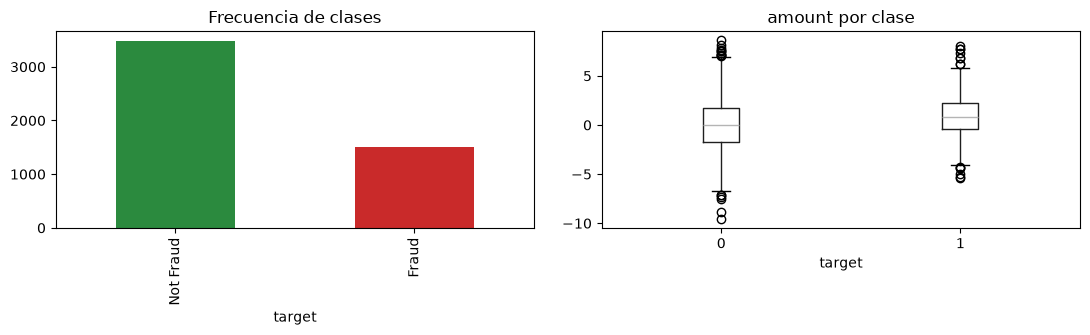

In [3]:
from fraud_mlops import dataset

df = dataset.make_fraud_dataframe(seed=42)

print("Dimensions:", df.shape)
print(df[config.TARGET_COL].value_counts(normalize=True).rename("proportion"))
dataset.plot_overview(df)


## 4. S3

We upload the **raw** CSV to the *landing zone* `s3://…/<prefix>/ingest/raw.csv`. That prefix
is the one **EventBridge** will watch to trigger the pipeline when new data arrives.


In [4]:
raw_data_s3 = dataset.upload_dataframe(sessions, df)
probe_df = dataset.sample_probe(df)      # 5 sample rows for section 13

print("Raw data in S3:", raw_data_s3)
print("Sample rows kept in memory:", probe_df.shape)


Datos crudos en S3: s3://sagemaker-us-east-1-872515265427/fraud-mlops/ingest/raw.csv
Ejemplo de filas guardado en memoria: (5, 21)


## 5. Data Processing

A `ScriptProcessor` with the **Scikit-learn** container:

1. Reads the raw CSV from S3 (the path comes from the **pipeline parameter** `InputData`).
2. Splits into `train / validation / test` (target first, no header → XGBoost CSV format).
3. Trains a **simple baseline** (`LogisticRegression`) and writes `baseline.json`.

The **baseline** is the reference model: the pipeline compares (outside the DAG) the main
model (XGBoost) against it.


## 6. Training

The main model is **XGBoost** (SageMaker-managed container) trained with `ModelTrainer`. The
metric is configurable, but by default we use `roc_auc` because it is more informative than
accuracy on imbalanced data (30% fraud).


## 7. Evaluation

The evaluation `ScriptProcessor` loads the training `model.tar.gz`, evaluates it with the
classification metrics and writes `evaluation.json`. The **ConditionStep** cannot change the
JSON path dynamically: that is why [`code/evaluate.py`](code/evaluate.py) receives `--metric`
(a **pipeline parameter**) and stores the chosen metric under the **fixed** key
`binary_classification_metrics.metric.value`. So changing `MetricName` on every run really
changes the criterion that opens the PASS/FAIL branch.


## 8. Conditional Logic

The **ConditionStep** decides with the configured metric:

```text
IF  metric (JsonGet) >= threshold (parameter)  -> PASS  -> Model Registry
ELSE                                           -> FAIL  -> FailStep
                                                            -> run in Failed state
                                                            -> EventBridge (fraud-pipeline-failed-alert rule)
                                                            -> SNS -> email
```

* `metric_threshold` is a **pipeline parameter**: you can change it on every run.
* On FAIL nothing is registered and nothing is deployed.
* The FailStep does **not** send the email: it only moves the run to `Failed`.
  The notification comes from an **EventBridge rule** that watches that state (section 11).


## 9. Model Registry

Only if `metric_value >= metric_threshold` the model is registered:

* `ModelMetrics` attaches `evaluation.json` as model metadata (human review).
* `ModelStep` + `ModelBuilder.register(...)` create the registration step in the DAG.
* `approval_status` is a parameter: by default **`PendingManualApproval`** (human review).
  If you pass `ModelApprovalStatus = Approved`, the run ends up approved automatically.

We create the registration group if it does not exist (idempotent):


In [5]:
from fraud_mlops import deploy

deploy.ensure_model_package_group(sessions)


[10/08/26 07:53:09] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=15312375;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=15312376;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

Grupo creado: fraud-detection-mlops-mpg-3569


## 10. Pipeline

`build_pipeline()` joins every step in the DAG (definition in
[`src/fraud_mlops/pipeline.py`](src/fraud_mlops/pipeline.py)). Note: **the pipeline does NOT
deploy by itself**. The *integration* with production happens in the Model Registry and
**the approval triggers the deploy** in section 12 (standard pattern: *deploy never deploys
what is not approved*).


In [5]:
from fraud_mlops.pipeline import build_pipeline, preview_definition

pipeline = build_pipeline(sessions, input_data_s3=raw_data_s3)

preview = preview_definition(pipeline)     # only serializes; does NOT run the pipeline
print("Pipeline:", pipeline.name)
print("Steps:", [s["Name"] for s in preview["Steps"]])
print("Parameters:", [p["Name"] for p in preview["Parameters"]])


[10/08/26 09:51:46] INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=9830329;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=9830330;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

[10/08/26 09:51:48] INFO     Ignoring unnecessary Python version: py3.                            ]8;id=9830337;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=9830338;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/image_uris.py#618\618]8;;\

                    INFO     Ignoring unnecessary instance type: ml.m5.large.                     ]8;id=9830344;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/image_uris.py\image_uris.py]8;;\:]8;id=9830345;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/image_uris.py#545\545]8;;\

                    INFO     SageMaker Python SDK will collect telemetry to help us better ]8;id=9830352;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/telemetry/telemetry_logging.py\telemetry_logging.py]8;;\:]8;id=9830353;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/telemetry/telemetry_logging.py#325\325]8;;\
                             understand our user's needs, diagnose issues, and deliver                             
                             additional features.                                                                  
                             To opt out of telemetry, please disable via TelemetryOptOut                           
                             parameter in SDK defaults config. For more information, refer                         
                             to                                                                                    
                             https://sagemaker.readthedocs.io/en/stable/overview.html#conf                         
                             iguring-and-using-defaults-with-the-sagemaker-python-sdk.                             

/home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/pipeline_context.py:341: UserWarning: Running within a PipelineSession, there will be No Wait, No Logs, and No Job being started.
  warnings.warn(


...

                    WARNING  Popping out 'TrainingJobName' from the pipeline definition by default ]8;id=9830401;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=9830402;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             since it will be overridden at pipeline execution time. Please                        
                             utilize the PipelineDefinitionConfig to persist this field in the                     
                             pipeline definition if desired.                                                       

[10/08/26 09:51:53] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=9830407;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=9830408;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'CertifyForMarketplace' from the pipeline definition     ]8;id=9830415;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/mlops/workflow/model_step.py\model_step.py]8;;\:]8;id=9830416;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/mlops/workflow/model_step.py#196\196]8;;\
                             since it will be overridden in pipeline execution time.                               

                    WARNING  Popping out 'ModelPackageName' from the pipeline definition by        ]8;id=9830421;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=9830422;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

Pipeline: fraud-detection-mlops
Steps: ['SplitData', 'TrainFraudXGB', 'EvaluateFraud', 'CheckFraudMetric']
Parametros: ['InputData', 'TrainingInstanceType', 'MetricName', 'MetricThreshold', 'ModelApprovalStatus']


### ⚠️ COST WARNING

This section **launches the pipeline on AWS** (creates/uses resources that incur cost):

* **What is created:** Processing jobs (split + eval) and Training (XGBoost `ml.m5.large`),
  plus a version in the Model Registry. ~10-15 min per run. Rough cost: **cents** per run.
* **How to minimize it:** small instances (`ml.m5.large`) and the **pipeline caching** on
  `SplitData`/`EvaluateFraud` avoid re-running steps when the input has not changed.
* **How to remove it:** section **14. Cleanup**.


In [7]:
from fraud_mlops import runner

# Run parameters. Change them here to try other configurations:
#   - ModelApprovalStatus="Approved"  -> auto-approves (no human step)
#   - MetricName="f1", MetricThreshold=0.55 -> a different evaluation criterion
run_params = config.build_run_params(raw_data_s3)
execution_arn = runner.upsert_and_start(sessions, pipeline, run_params)


[10/08/26 07:54:27] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=15312473;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312474;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'TrainingJobName' from the pipeline definition by default ]8;id=15312479;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312480;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             since it will be overridden at pipeline execution time. Please                        
                             utilize the PipelineDefinitionConfig to persist this field in the                     
                             pipeline definition if desired.                                                       

[10/08/26 07:54:28] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=15312485;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312486;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'ModelPackageName' from the pipeline definition by        ]8;id=15312491;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312492;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

Execution ARN: arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops/execution/ki5wwlahsesm


In [8]:
status = runner.wait_execution(sessions, execution_arn)
runner.report_steps(sessions, execution_arn)

print("Final status:", status)
if status != "Succeeded":
    print("Check FailureReason in the SageMaker Pipelines console.")


  07:54:58 -> Executing
  07:55:18 -> Executing
  07:55:38 -> Executing
  07:55:58 -> Executing
  07:56:18 -> Executing
  07:56:39 -> Executing
  07:56:59 -> Executing
  07:57:19 -> Executing
  07:57:39 -> Executing
  07:57:59 -> Executing
  07:58:20 -> Executing
  07:58:40 -> Executing
  07:59:00 -> Executing
  07:59:21 -> Executing
  07:59:41 -> Executing
  08:00:01 -> Executing
  08:00:21 -> Executing
  08:00:41 -> Executing
  08:01:02 -> Executing
  08:01:22 -> Executing
  08:01:42 -> Executing
  08:02:02 -> Executing
  08:02:22 -> Executing
  08:02:43 -> Executing
  08:03:03 -> Executing
  08:03:23 -> Executing
  08:03:44 -> Executing
  08:04:04 -> Executing
  08:04:24 -> Executing
  08:04:45 -> Executing
  08:05:05 -> Executing
  08:05:25 -> Succeeded
  RegisterFraudModel     -> Succeeded
  CheckFraudMetric       -> Succeeded
  EvaluateFraud          -> Succeeded
  TrainFraudXGB          -> Succeeded
  SplitData              -> Succeeded
Estado final: Succeeded


In [9]:
if status == "Succeeded":
    comparison = runner.compare_with_baseline(sessions, threshold=config.METRIC_THRESHOLD)
    display(comparison)
else:
    print("The pipeline did not reach Succeeded; check the console before continuing.")


Metrica elegida: roc_auc = 0.9743  (umbral: 0.7)
-> PASS


,Metric,Baseline (LogisticRegression),Principal (XGBoost)
0,accuracy,0.8310,0.9370
1,precision,0.7597,0.9286
2,recall,0.6469,0.8581
3,f1,0.6988,0.8919
4,roc_auc,0.9027,0.9743


## 11. Event Trigger and Alerts

Complete event architecture (no Lambdas):

```text
S3 (ObjectCreated on ingest/) -> EventBridge -> SageMaker Pipeline   [rule 1]
Pipeline Executing (start)    -> EventBridge -> SNS -> email        [rule 2]
Pipeline Failed  (failure)    -> EventBridge -> SNS -> email        [rule 3]
```

* **Rule 1** `fraud-new-data-trigger`: `ObjectCreated` on `ingest/` → native SageMaker target
  with `SageMakerPipelineParameters`.
* **Rule 2** `fraud-pipeline-started-alert`: `detail.currentPipelineExecutionStatus = Executing`.
* **Rule 3** `fraud-pipeline-failed-alert`: `detail.currentPipelineExecutionStatus = Failed`.
* The alert rules filter on `detail.pipelineArn` (the ARN prefix of this pipeline).
  That is the **real** event field: `PipelineName` / `PipelineExecutionStatus` **do not exist**
  in the payload and a pattern using them never matches (the original failure of this demo).
* The SNS topic needs `events.amazonaws.com -> sns:Publish` in its **policy**
  (`ensure_sns_topic` adds it). Without that permission EventBridge cannot publish and
  **nothing arrives**, even though the rule does fire.
* The email subscription must be **confirmed** from the SNS welcome email.


In [6]:
events_role_arn = events.ensure_events_role(sessions)
topic_arn = events.ensure_sns_topic(sessions)
events.ensure_event_rules(sessions, events_role_arn, topic_arn, input_data_s3=raw_data_s3)

# Cheap verification (runs no pipeline and sends no emails):
#   1) the patterns match the real event documented by SageMaker
#   2) the EventBridge -> SNS -> email chain is healthy
events.check_event_patterns(sessions)
events.diagnose_alerts(sessions, topic_arn)


Pipeline ARN: arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops
Rol ya existia: fraud-mlops-events-role
Politica adjunta al rol de eventos.
Topic SNS: arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts
Politica SNS ya permite publicar desde EventBridge.
Suscripcion confirmada para alertas: huillcas.juan3@gmail.com
Regla vigente: fraud-new-data-trigger -> arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops
Regla vigente: fraud-pipeline-failed-alert -> arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts
Regla vigente: fraud-pipeline-started-alert -> arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts
OK   patron fraud-pipeline-failed-alert con status Failed: casa
OK   patron fraud-pipeline-failed-alert con status Succeeded: no casa
OK   patron fraud-pipeline-started-alert con status Executing: casa
OK   patron fraud-pipeline-started-alert con status Failed: no casa
OK   politica SNS: EventBridge -> sns:Publish permitido.
OK   suscripcion e

{'topic_arn': 'arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts',
 'rules': {'fraud-new-data-trigger': {'exists': True,
   'state': 'ENABLED',
   'pattern': '{"source": ["aws.s3"], "detail-type": ["Object Created"], "detail": {"bucket": {"name": ["sagemaker-us-east-1-872515265427"]}, "object": {"key": [{"prefix": "fraud-mlops/ingest/"}]}}}',
   'targets': ['arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops']},
  'fraud-pipeline-failed-alert': {'exists': True,
   'state': 'ENABLED',
   'pattern': '{"source": ["aws.sagemaker"], "detail-type": ["SageMaker Model Building Pipeline Execution Status Change"], "detail": {"currentPipelineExecutionStatus": ["Failed"], "pipelineArn": [{"prefix": "arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops"}]}}',
   'targets': ['arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts']},
  'fraud-pipeline-started-alert': {'exists': True,
   'state': 'ENABLED',
   'pattern': '{"source": ["aws.sagemaker"], "detai

### ⚠️ COST WARNING — Trigger demonstration

Uploading a new CSV will trigger **a full pipeline run** (~10-15 min, `ml.m5.large`).

Optional: you can skip this step and run section 12 with the already registered version.


In [11]:
# We simulate a new data delivery: another synthetic CSV in the same landing zone.
df_nuevo = dataset.make_fraud_dataframe(seed=999)
print("df_nuevo:", df_nuevo.shape,
      "| target proportion:",
      df_nuevo[config.TARGET_COL].value_counts(normalize=True).round(3).to_dict())

dataset.upload_dataframe(sessions, df_nuevo)   # same key -> EventBridge triggers the pipeline
print("New CSV uploaded -> EventBridge should trigger the pipeline...")


df_nuevo: (5000, 21) | proporcion target: {0: 0.695, 1: 0.305}
Nuevo CSV subido -> EventBridge deberia disparar el pipeline...


In [12]:
# Wait until the running execution shows up (triggered automatically)
auto_exec = events.wait_for_automatic_execution(sessions)


Disparado automaticamente! Nueva ejecucion: arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops/execution/c4la54q6gks4


In [13]:
# (Optional) Wait for that run and publish a test message to SNS
if auto_exec and auto_exec["PipelineExecutionStatus"] == "Executing":
    status_auto = runner.wait_execution(sessions, auto_exec["PipelineExecutionArn"])
    print("Final status of the EventBridge-triggered run:", status_auto)
else:
    status_auto = "no disponible"

if topic_arn:
    events.publish_alert(sessions, topic_arn,
                         subject="Fraud MLOps",
                         message=f"Ejecucion '{auto_exec}' -> {status_auto}")


  08:09:04 -> Executing
  08:09:24 -> Executing
  08:09:44 -> Executing
  08:10:04 -> Executing
  08:10:24 -> Executing
  08:10:45 -> Executing
  08:11:05 -> Executing
  08:11:25 -> Executing
  08:11:45 -> Executing
  08:12:05 -> Executing
  08:12:26 -> Executing
  08:12:46 -> Executing
  08:13:06 -> Executing
  08:13:26 -> Executing
  08:13:47 -> Executing
  08:14:07 -> Executing
  08:14:27 -> Executing
  08:14:47 -> Executing
  08:15:07 -> Succeeded
Estado final de la ejecucion disparada por EventBridge: Succeeded
Mensaje SNS publicado.


### ⚠️ COST WARNING — (Optional) Demonstrate the FAIL branch + alert

With an impossible threshold (0.99) the PASS never happens: the run ends in **Failed** and the
`fraud-pipeline-failed-alert` rule publishes to SNS → failure email. Since every run goes
through `Executing` first, you will also get the **start** email
(`fraud-pipeline-started-alert`). It generates one extra run (or only a few seconds if the
steps hit the cache).


In [18]:
run_fail_arn = runner.upsert_and_start(
    sessions, pipeline, config.build_run_params(raw_data_s3, MetricThreshold=0.99))

status_fail = runner.wait_execution(sessions, run_fail_arn)
runner.report_steps(sessions, run_fail_arn)

print("Final status (expected Failed):", status_fail)
assert status_fail == "Failed", f"Expected Failed but got {status_fail}"


[10/08/26 09:25:05] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=15312629;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312630;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'TrainingJobName' from the pipeline definition by default ]8;id=15312635;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312636;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             since it will be overridden at pipeline execution time. Please                        
                             utilize the PipelineDefinitionConfig to persist this field in the                     
                             pipeline definition if desired.                                                       

[10/08/26 09:25:06] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=15312641;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312642;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'ModelPackageName' from the pipeline definition by        ]8;id=15312647;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312648;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

[10/08/26 09:25:08] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=15312653;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312654;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'TrainingJobName' from the pipeline definition by default ]8;id=15312659;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312660;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             since it will be overridden at pipeline execution time. Please                        
                             utilize the PipelineDefinitionConfig to persist this field in the                     
                             pipeline definition if desired.                                                       

[10/08/26 09:25:09] WARNING  Popping out 'ProcessingJobName' from the pipeline definition by       ]8;id=15312665;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312666;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

                    WARNING  Popping out 'ModelPackageName' from the pipeline definition by        ]8;id=15312671;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py\utilities.py]8;;\:]8;id=15312672;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/workflow/utilities.py#481\481]8;;\
                             default since it will be overridden at pipeline execution time.                       
                             Please utilize the PipelineDefinitionConfig to persist this field in                  
                             the pipeline definition if desired.                                                   

Execution ARN: arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops/execution/5718zlu8bh6x
  09:25:11 -> Executing
  09:25:31 -> Executing
  09:25:51 -> Executing
  09:26:12 -> Executing
  09:26:32 -> Executing
  09:26:52 -> Executing
  09:27:12 -> Executing
  09:27:32 -> Executing
  09:27:53 -> Executing
  09:28:13 -> Executing
  09:28:33 -> Executing
  09:28:53 -> Executing
  09:29:13 -> Executing
  09:29:34 -> Executing
  09:29:54 -> Executing
  09:30:15 -> Executing
  09:30:35 -> Executing
  09:30:55 -> Executing
  09:31:15 -> Executing
  09:31:35 -> Executing
  09:31:56 -> Executing
  09:32:16 -> Executing
  09:32:36 -> Executing
  09:32:56 -> Executing
  09:33:16 -> Executing
  09:33:36 -> Failed
  FraudThresholdNotMet   -> Failed
  CheckFraudMetric       -> Succeeded
  EvaluateFraud          -> Succeeded
  TrainFraudXGB          -> Succeeded
  SplitData              -> Succeeded
Estado final (esperado Failed): Failed


### Alert verification (read only)

We check with CloudWatch metrics whether the rules **fired** on that run
(`TriggeredRules`) and whether SNS **published** the emails. Metrics take ~1 min to appear.


In [20]:
report = events.diagnose_alerts(sessions, topic_arn, hours=1)
report["metrics"]


OK   politica SNS: EventBridge -> sns:Publish permitido.
OK   suscripcion email=huillcas.juan3@gmail.com: confirmada.
OK   regla fraud-new-data-trigger: ENABLED -> arn:aws:sagemaker:us-east-1:872515265427:pipeline/fraud-detection-mlops
OK   regla fraud-pipeline-failed-alert: ENABLED -> arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts
OK   regla fraud-pipeline-started-alert: ENABLED -> arn:aws:sns:us-east-1:872515265427:fraud-mlops-alerts
Metricas 1h fraud-pipeline-failed-alert -> disparada: 1.0 | invocaciones fallidas: 0
Metricas 1h fraud-pipeline-started-alert -> disparada: 1.0 | invocaciones fallidas: 0
Metricas 1h -> SNS publicados: 4.0
=> alertas listas


## 12. Deployment

Golden rule of the project: **what is not approved does not get deployed**.

1. List the Model Registry versions and their approval status.
2. If `ApprovalStatus != Approved`, **block the deploy** (gate: manual/configured).
3. Only with `Approved` we create `Model` → `EndpointConfig` → **Real-Time Endpoint** (`ml.m5.large`).

In production the approval comes from a human (console) or an external process (Lambda/CI). Here
we demonstrate it with step 2 and keep the deploy conditioned on that real state.


In [15]:
version = deploy.latest_model_version(sessions)
latest_arn = version["ModelPackageArn"]

deploy.ensure_approved(sessions, latest_arn)

# Idempotent: if the endpoint already exists, it does NOT deploy again
endpoint, created = deploy.ensure_endpoint(sessions, latest_arn)
print("Endpoint created in this session:", created)


{'version': 2, 'status': 'Completed', 'approval': 'PendingManualApproval'}
{'version': 1, 'status': 'Completed', 'approval': 'PendingManualApproval'}
Estado de aprobacion: PendingManualApproval
GATE: NO se despliega sin aprobacion. Permitimos la aprobacion aqui (simula el humano/config):
Version aprobada: OK


[10/08/26 08:25:19] DEBUG    No boto3 session provided. Creating a new session.                        ]8;id=15312547;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=15312548;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#346\346]8;;\

                    WARNING  No region provided. Using default region.                                 ]8;id=15312554;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=15312555;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#350\350]8;;\

                    DEBUG    No config provided. Using default config.                                 ]8;id=15312561;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/utils/utils.py\utils.py]8;;\:]8;id=15312562;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/core/utils/utils.py#354\354]8;;\

                    INFO     Found credentials in shared credentials file: ~/.aws/credentials   ]8;id=15312567;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py\credentials.py]8;;\:]8;id=15312568;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/botocore/credentials.py#1392\1392]8;;\

...

169.254.178.2 - - [07/Oct/2026:19:30:25 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"

169.254.178.2 - - [07/Oct/2026:19:30:28 +0000] "GET /metrics HTTP/1.1" 404 2 "-" "SageMakerOTelCollector/0.1.0"

169.254.178.2 - - [07/Oct/2026:19:30:30 +0000] "GET /ping HTTP/1.1" 200 0 "-" "AHC/2.0"

[10/08/26 08:28:53] INFO     ✅ Deployment successful: Endpoint 'fraud-detection-endpoint'    ]8;id=15312623;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/serve/model_builder.py\model_builder.py]8;;\:]8;id=15312624;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/serve/model_builder.py#3834\3834]8;;\
                             using None in SAGEMAKER_ENDPOINT mode (ARN:                                           
                             arn:aws:sagemaker:us-east-1:872515265427:endpoint/fraud-detectio                      
                             n-endpoint)                                                                           

Endpoint creado/en servicio: fraud-detection-endpoint
Estado endpoint: InService
Endpoint creado en esta sesion: True


## 13. Inference

Two ways to invoke the endpoint (both from this notebook, in Python):

1. **From Python (boto3)** → `sagemaker-runtime.invoke_endpoint`.
2. **From the notebook (SDK)** → the `Endpoint` object returned by `deploy` (if it was just created).

XGBoost (`text/csv`, no header) returns **one probability per line**; the class is
`prob >= 0.5`.


In [16]:
from fraud_mlops import inference

preds = inference.predict_dataframe(sessions, probe_df, endpoint=endpoint)
display(preds[[*config.FEATURE_COLS, config.TARGET_COL, "probability", "prediction"]])


,time,amount,v01,v02,v03,v04,v05,v06,v07,v08,...,v12,v13,v14,v15,v16,v17,v18,target,probability,prediction
3406,-4.258536,1.844517,0.549491,-1.035844,3.163905,-4.456896,-1.564651,-0.558949,3.137031,2.088963,...,0.445897,3.866336,-5.681868,-0.366358,4.012493,2.271688,2.769950,0,0.001951,0
757,2.679361,-0.131373,2.147165,-2.495084,6.145855,-1.365386,-1.318673,0.192058,1.270919,0.783905,...,-1.283920,3.271016,0.782971,-0.792530,-3.571355,1.046164,-0.294784,1,0.905420,1
3624,-0.805674,0.859968,0.026107,-1.689406,1.952273,-1.624284,-0.640234,0.945242,3.223219,4.311797,...,-0.330896,0.310276,-0.296896,-1.981777,-0.955262,4.633269,-1.076653,1,0.999442,1
4544,1.249925,0.123937,4.867644,-4.664947,7.317832,1.813501,-3.516791,-0.049670,4.848495,2.101238,...,-0.533209,-1.900124,-3.518788,-15.138148,2.898421,-1.426579,-4.157134,1,0.997988,1
3235,-0.594125,0.796503,3.525808,0.940789,2.773900,-1.894658,-2.847924,-0.694321,2.548562,0.462861,...,-0.652912,0.516053,-0.543871,-5.583427,1.464893,-0.431897,0.329259,0,0.519814,1


In [17]:
row = probe_df.iloc[2]
prob = inference.predict_row(sessions, row, endpoint=endpoint)

print("Probability:", round(prob, 4))
print("Class    :", "FRAUD" if prob >= 0.5 else "NOT FRAUD",
      f"(true label: {'FRAUD' if row[config.TARGET_COL] == 1 else 'NOT FRAUD'})")


Probabilidad: 0.9994
Clase    : FRAUD (label real: FRAUD)


## 14. Cleanup

**Essential when you finish the lab** so you do not keep paying:

* Endpoint + EndpointConfig + Model.
* Pipeline (definition).
* Project Model Registry groups (versions included, with retries).
* EventBridge rules + events role + SNS topic.
* **S3 → EventBridge** notification on the bucket (disabled by the cleanup itself).
* (Optional, warned) S3 data under the project prefix.

> ⚠️ **If you touched `src/` during the session** (e.g. `config.py`), the kernel is still using
> the copy it imported at the beginning: **restart the kernel** and re-run the configuration
> cell (and any you need) **before** this one. Otherwise you will get
> `AttributeError: module 'fraud_mlops.config' has no attribute ...`.


### ⚠️ COST WARNING

Deleting the **endpoint** stops the live instance billing (the biggest expense of the project).


In [7]:
from fraud_mlops import cleanup

cleanup.cleanup_resources(sessions, pipeline=pipeline, topic_arn=topic_arn)
cleanup.cleanup_s3(sessions, delete=False)   # True -> deletes the whole project prefix


== Limpieza endpoint/model ==
- Endpoint: An error occurred (ValidationException) when calling the DeleteEndpoint operation: Could not find endpoint "fraud-detection-endpoint".
- EndpointConfig: An error occurred (ValidationException) when calling the DeleteEndpointConfig operation: Could not find endpoint configuration "fraud-detection-endpoint".
- Model: An error occurred (ValidationException) when calling the DeleteModel operation: Could not find model "fraud-detection-xgboost".
== Limpieza pipeline ==


[10/08/26 09:52:54] INFO     If triggers have been setup for this target, they will become          ]8;id=9830429;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/mlops/workflow/pipeline.py\pipeline.py]8;;\:]8;id=9830430;file:///home/charly/dev/public/sagemaker-pipelines-fraud-detection/.venv/lib/python3.12/site-packages/sagemaker/mlops/workflow/pipeline.py#408\408]8;;\
                             orphaned.You will need to clean them up manually via the CLI or                       
                             EventBridge console.                                                                  

- Pipeline: ya no existe
== Limpieza EventBridge / SNS / IAM ==
- Regla borrada: fraud-new-data-trigger
- Regla borrada: fraud-pipeline-failed-alert
- Regla borrada: fraud-pipeline-started-alert
- S3 -> EventBridge desactivado en s3://sagemaker-us-east-1-872515265427
- Rol borrado: fraud-mlops-events-role
- Topic SNS borrado
Cleanup completado (los datos en S3 se conservan; borra el prefijo si quieres con cleanup_s3(delete=True)).
S3 no se toco (delete=False); borraria s3://sagemaker-us-east-1-872515265427/fraud-mlops/ si lo activas.


## Key Takeaways

* **E2E pipeline**: Split → Train → Evaluate → Conditional → Register. It does NOT deploy by itself.
* The **metric and threshold** are pipeline parameters (the metric is chosen in `MetricName`).
* **Conditional**: `metric >= threshold` → registers; otherwise → `FailStep` → run `Failed`.
* **Alerts**: EventBridge sends the email, not the FailStep. There are **3 rules**:
  new data → launches the pipeline; `Executing` → start email; `Failed` → failure email.
  Requirements: a pattern with `detail.currentPipelineExecutionStatus` + `detail.pipelineArn`,
  an SNS policy with `events.amazonaws.com` and a confirmed email subscription.
* **Model Registry**: `PendingManualApproval` by default; deploy is blocked until approved.
* **Event Trigger**: S3 (`ObjectCreated` on `ingest/`) → EventBridge → just launches the pipeline.
* **Cost**: small instances + caching + delete the endpoint when you are done.
* **Reusable code**: the logic lives in `src/fraud_mlops/`; this notebook only orchestrates
  the demo and documents each step.
